### Robot Learning

### Assignment 06

Solutions are due on 27.05.2025 before the lecture.

The following problem is known as the *tiger problem* and goes back to Cassandra, Littman and Kaelbling ($1994$).

A person faces two doors. Behind one, there is a tiger, behind the other, there is a reward of $+1000$. Initially, the person has no information behind which door the tiger or the reward are.

The person can either listen or open one of the doors.

When the door with the tiger behind it is opened, the person will be eaten, which has an associated cost of $–1600$.

Listening costs $–20$. When listening, the person will hear a roaring noise that indicates the presence of a tiger, but only with $0.75$ probability will the person be able to localize the noise correctly. With $0.25$ probability, the noise will appear as if it came from the door hiding the reward.

## Task 6.1)

Provide a formal model of the POMDP, in which you define the state, action, and measurement
spaces, the cost function, and the associated probability functions.

<div style="text-align: right; font-weight:bold"> 4 Points </div>

Please answer in this text cell. It is possible to create tables:

|<i> $p(x_i | x_j , a_L)$ <i> | $j=0$ | $j=1$ |
|------|------|------|
|   $i=0$  | $1$| $0$ |
|   $i=1$  | $0$| $1$ |


# states 0 and 1
X = [0,1]  tiger in door 0 or 1

# actions listen, open door 0, open door 1
A = ['listen', 'open d0', 'open d1']

# measurement spaces hear door 0 or door 1
z  =[0, 1]  tiger roaring behind door 0 or 1

# cost functions 
listen_cost = -20
tiger_cost =-1600
reward = 1000

# transition probabilities 
0.75  probability of hearing the tiger behind door 0
0.25  probability of the tiger being behind door 0 after listening

0.75  probability of hearing the tiger behind door 1
0.25  probability of the tiger being behind door 1 after listening

## Task 6.2)

What is the expected cumulative reward/cost of the open-loop action sequence: “Listen, listen,open door 1”? Explain your calculation!

<div style="text-align: right; font-weight:bold"> 2 Points </div>

In [1]:
from POMDP import *
pomdp = POMDP()

sequence1 = ['listen', 'listen', 'open door1']
reward1 = pomdp.expected_reward(sequence1)
print(f"Expected reward for sequence {sequence1} is {reward1}")

Expected reward for sequence ['listen', 'listen', 'open door1'] is -340.0


Please answer in this text cell.
# -340


## Task 6.3)

What is the expected cumulative reward/cost of the action sequence: “Listen, then open the door for which you did not hear a noise”? Again, explain your calculation!

<div style="text-align: right; font-weight:bold"> 4 Points </div>

In [2]:
def value_iteration(pomdp):

    belief_space = np.linspace(0,1,100)

    V_open_door0 = np.array([pomdp.reward_function(0, 'open_door0')*b+
                                pomdp.reward_function(1, 'open_door0')*(1-b) for b in belief_space])
    
    V_open_door1 = np.array([pomdp.reward_function(0, 'open_door1')*b+
                                pomdp.reward_function(1, 'open_door1')*(1-b) for b in belief_space])
    
    V_listen = np.zeros_like(belief_space)

    for i,b in enumerate(belief_space):
        belief = np.array([b, 1-b])

        exp_reward = pomdp.listen_cost

        future = 0
        for obs in pomdp.observations:
            p_obs = sum(pomdp.obs_function(s, 'listen', obs) * belief[s] for s in pomdp.states)
            if p_obs > 0:
                new_belief = pomdp.belief_update(belief, 'listen', obs)
                
                door1 = new_belief[0] * pomdp.reward_function(0, 'open door1') +\
                        new_belief[1] * pomdp.reward_function(1, 'open door1')
                door0 = new_belief[0] * pomdp.reward_function(0, 'open door0') +\
                        new_belief[1] * pomdp.reward_function(1, 'open door0')
                future += p_obs * max(door0, door1)
        V_listen[i] = exp_reward + future
    V = np.maximum.reduce([V_open_door0, V_open_door1, V_listen])
    return belief_space, V_open_door0, V_open_door1, V_listen, V

In [7]:
initial_belief = np.array([0.5, 0.5])  # Initial belief state
prob_door1 =  sum(pomdp.obs_function(s, 'listen', 0) * initial_belief[s] for s in pomdp.states)
prob_door0 = 1- prob_door1

belief_door1 = pomdp.belief_update(initial_belief, 'listen', 0)
reward_door1 = sum(belief_door1[s] * pomdp.reward_function(s, 'open door1') for s in pomdp.states)  

belief_door0 = pomdp.belief_update(initial_belief, 'listen', 1)
reward_door0 = sum(belief_door0[s] * pomdp.reward_function(s, 'open door0') for s in pomdp.states)

total_reward = pomdp.listen_cost + prob_door1 * reward_door1 + prob_door0 * reward_door0
print(f"Total expected reward for initial belief {initial_belief} is {total_reward}")


Total expected reward for initial belief [0.5 0.5] is -320.0


Please answer in this text cell.

## Task 6.4)

Perform the one-step backup operation of the POMDP. Plot the resulting piecewise linear value functions in a diagram, just like the ones presented in the lecture. Provide diagrams for all intermediate steps.

Hint: This task is possible to solve on paper, but somewhat tedious. We recommend writing a script to solve it.

<div style="text-align: right; font-weight:bold"> 10 Points </div>

In [4]:
# Your code could go here...

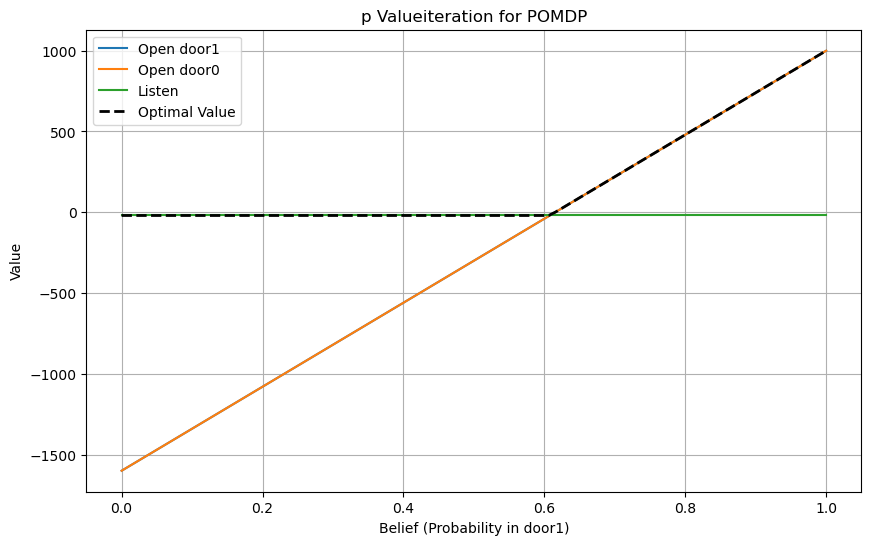

In [8]:

import matplotlib.pyplot as plt

def plot_value_functions(belief_space, V_open_left, V_open_right, V_listen, V_optimal):
    plt.figure(figsize=(10, 6))
    plt.plot(belief_space, V_open_left, label='Open door1')
    plt.plot(belief_space, V_open_right, label='Open door0')
    plt.plot(belief_space, V_listen, label='Listen')
    plt.plot(belief_space, V_optimal, 'k--', label='Optimal Value', linewidth=2)
    plt.xlabel('Belief (Probability in door1)')
    plt.ylabel('Value')
    plt.title('p Valueiteration for POMDP')
    plt.legend()
    plt.grid(True)
    plt.show()



# Task 6.4: One-step backup operation
belief_space, V_open_left, V_open_right, V_listen, V_optimal = value_iteration(pomdp)
plot_value_functions(belief_space, V_open_left, V_open_right, V_listen, V_optimal)

... or you could answer in this text cell.